KeyboardInterrupt: 

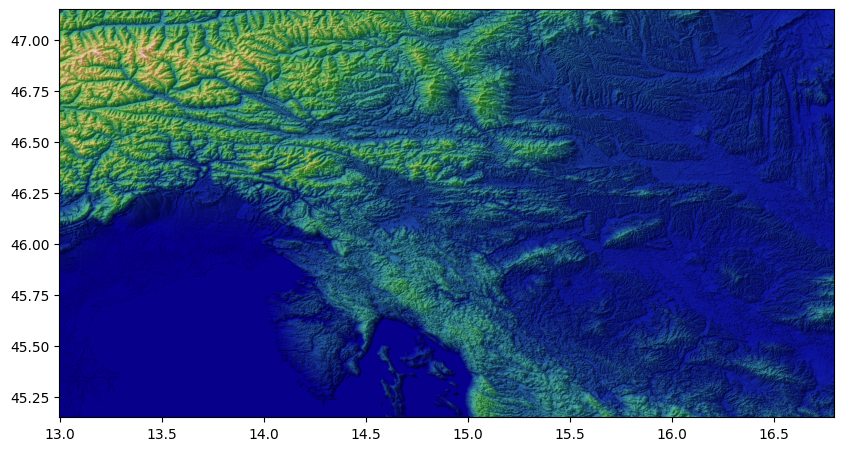

In [2]:
from osgeo import gdal
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LightSource, LinearSegmentedColormap
import matplotlib.colors as mcolors

# Load the SRTM data for shading
shading_dataset = gdal.Open(r'../data/shading/srtm_slo_250.tif')
shading_band = shading_dataset.GetRasterBand(1)
shading_data = shading_band.ReadAsArray()

# Load your temperature data (replace this with your actual temperature data)
temperature_data = np.random.uniform(-20, 40, shading_data.shape)  # Replace with your data

# Create a Matplotlib figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Create a light source for shading to simulate a 3D effect
ls = LightSource(azdeg=315, altdeg=45)

cmap_gist_earth = plt.cm.get_cmap('gist_earth')

# Apply shading to the SRTM data to make it look 3D
shaded_relief = ls.shade(shading_data, cmap=cmap_gist_earth, vert_exag=1.0, blend_mode='soft')

# Define bounding coordinates
LAT_MIN = 45.1512
LAT_MAX = 47.1512
LON_MIN = 12.9955
LON_MAX = 16.7955

# Display the shaded SRTM data within the specified bounding coordinates
ax.imshow(
    shaded_relief,
    extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
    cmap='gist_earth',
    alpha=1.0
)

# Create a custom colormap for temperature
temperature_colors = ['#0000FF', '#00FFFF', '#00FF00', '#FFFF00', '#FF0000']  # Adjust these colors as needed
cmap_temperature = LinearSegmentedColormap.from_list('temperature_cmap', temperature_colors, N=500)

# Define contour levels for temperature
temperature_contour_levels = list(range(-20, 42, 2))

# Create temperature contours within the bounding coordinates
contour = ax.contourf(
    temperature_data,
    levels=temperature_contour_levels,
    cmap=cmap_temperature,
    extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
    alpha=0.7
)

# Add a colorbar for the temperature data
cbar_temperature = plt.colorbar(contour, ax=ax, label='Temperature (°C)', ticks=temperature_contour_levels)

# Customize your map as needed

# Save or display the resulting 2D map with a 3D-like appearance and custom temperature contours
plt.savefig('2DMapWith3DEffectAndCustomTemperatureContours.png')
plt.show()

1
